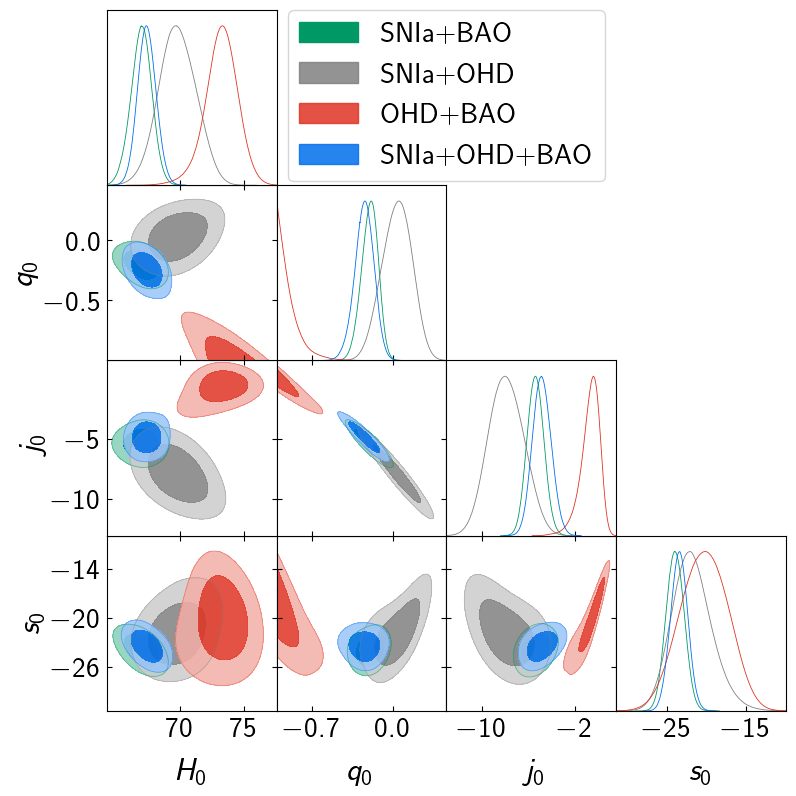

In [1]:
from getdist import plots
from getdist.styles.planck import style_name

g=plots.get_subplot_plotter(chain_dir=r'../chains')
roots = []
roots.append('sb')
roots.append('sc')
roots.append('cb')
roots.append('all')
params = ['H0', 'q0', 'j0', 's0']

g.settings.legend_fontsize = 24
g.settings.axes_fontsize=24
g.settings.axes_labelsize=26
plots.set_active_style(style_name)

g.triangle_plot(roots, params, legend_labels=[r'SNIa+BAO',r'SNIa+OHD',r'OHD+BAO','SNIa+OHD+BAO'], filled=True)
g.export('../results/contour.pdf')

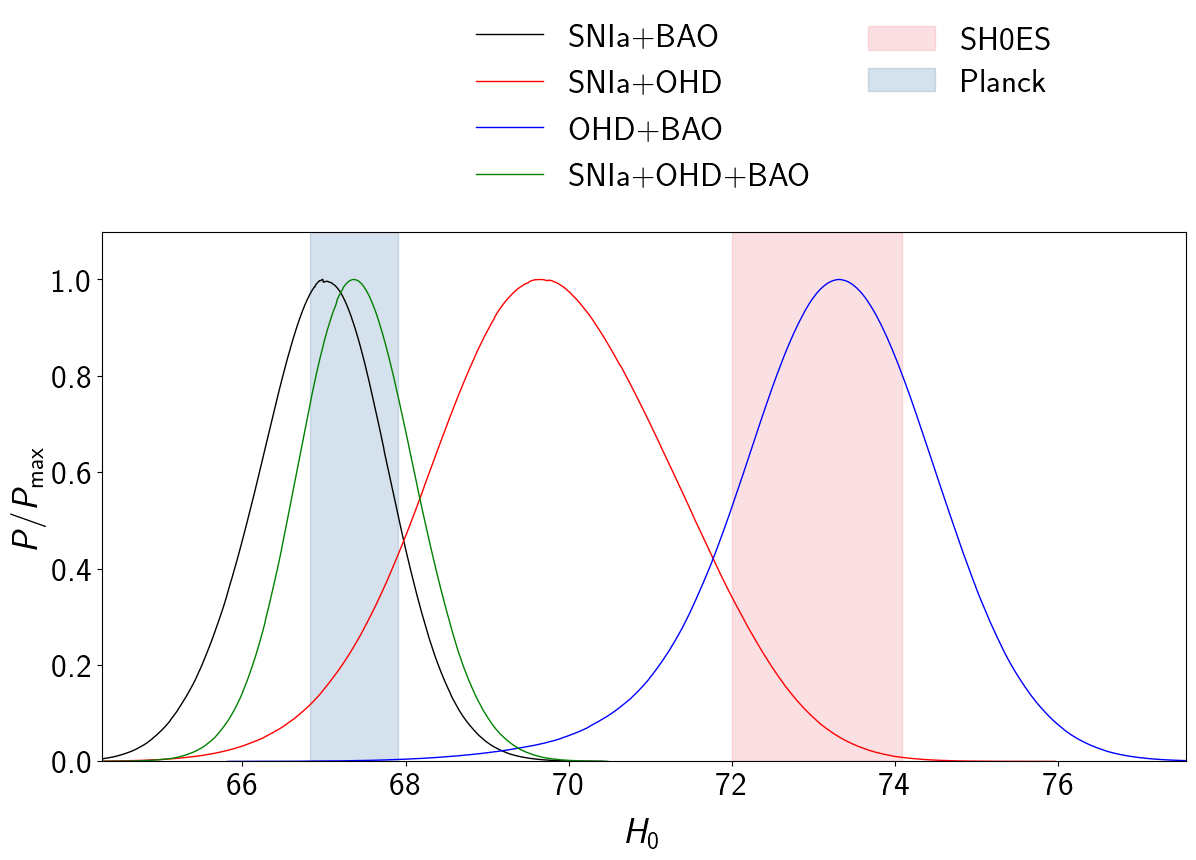

In [1]:
from getdist import plots
from getdist.styles.planck import style_name
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

plots.set_active_style(style_name)

g = plots.get_subplot_plotter(
    chain_dir=r'../chains',
    width_inch=12,
    subplot_size=12,
)

roots  = ['sb', 'sc', 'cb', 'all']
params = ['H0']

g.settings.legend_fontsize    = 24
g.settings.axes_fontsize      = 24
g.settings.axes_labelsize     = 26
g.settings.subplot_size_ratio = 0.8

g.plots_1d(
    roots, params,
    legend_labels=[r'SNIa+BAO', r'SNIa+OHD', r'OHD+BAO', 'SNIa+OHD+BAO'],
    filled=True,
)

# ---------------- Color definitions ----------------
color_SH0ES  = '#EE6677'   # soft coral red
color_Planck = '#4477AA'   # indigo blue

# ---------------- Add SH0ES H0 shaded band ----------------
H0_SH0ES  = 73.04
sigma_SH0ES = 1.04

ax_H0 = g.get_axes(['H0'])
g.add_x_bands(
    H0_SH0ES, sigma_SH0ES,
    ax=ax_H0,
    color=color_SH0ES,
    alpha1=0.20,    #1-sigma
    alpha2=0.,#0.08,    #2-sigma
)

# ---------------- Add Planck CMB H0 shaded band ----------------
H0_Planck   = 67.37
sigma_Planck = 0.54

g.add_x_bands(
    H0_Planck, sigma_Planck,
    ax=ax_H0,
    color=color_Planck,
    alpha1=0.22,    #1-sigma
    alpha2=0.,#0.10,    #2-sigma
)

# ---------------- Rearrange legend ----------------
# ---- 1) Extract the legend generated by plots_1d, then remove it ----
existing = ax_H0.get_legend()
if existing is not None:
    old_handles = getattr(existing, 'legend_handles', None) or existing.legendHandles
    old_labels  = [t.get_text() for t in existing.get_texts()]
    existing.remove()
else:
    old_handles, old_labels = [], []

# ---- 2) Proxy legend entries for the two shaded bands ----
proxy_SH0ES  = Patch(facecolor=color_SH0ES,  alpha=0.20, edgecolor=color_SH0ES)
proxy_Planck = Patch(facecolor=color_Planck, alpha=0.22, edgecolor=color_Planck)

# ---- 3) Legend 1: the four MCMC curves ----
leg1 = ax_H0.legend(
    list(old_handles), list(old_labels),
    fontsize=g.settings.legend_fontsize,
    loc='upper left',
    bbox_to_anchor=(0.5, 1.38),   # adjust position if needed
    frameon=False,
    labelspacing=0.35,
    handlelength=2.0,
)
ax_H0.add_artist(leg1)             # keep it, otherwise it will be overwritten by the next legend

# ---- 4) Legend 2: SH0ES + Planck, placed to the right of legend 1 ----
ax_H0.legend(
    [proxy_SH0ES, proxy_Planck],
    ['SH0ES', 'Planck'],
    fontsize=g.settings.legend_fontsize,
    loc='upper left',
    bbox_to_anchor=(0.70, 1.38),
    bbox_transform=ax_H0.figure.transFigure,
    frameon=False,
    labelspacing=0.35,
    handlelength=2.0,
)

g.fig.set_size_inches(12, 6)
g.export('../results/H0.pdf')